# Convergence: Random vs. Deterministic Isochromat Sampling

Verifies the theoretical convergence rates for the two B0-inhomogeneity sampling strategies
by measuring the error in the **first Hahn-echo amplitude** against a high-N ground truth.

| Method | Theoretical rate | Reason |
|---|---|---|
| Random (Monte Carlo) | $\mathcal{O}(1/\sqrt{N})$ | Central Limit Theorem |
| Deterministic (Shkarin & Spencer 1996) | $\mathcal{O}(1/N^2)$ | Gaussian quadrature rule |

**Ground truth:** one deterministic simulation with $N_\mathrm{GT} = 2001$ isochromats.  
**Error metric:** $|A_N - A_\mathrm{gt}| \;/\; A_\mathrm{gt}$ — relative error of the first echo amplitude.

In [13]:
from pathlib import Path
from datetime import datetime

import numpy as np
import torch
import pypulseq as pp
import matplotlib.pyplot as plt
import matplotlib as mpl
from tqdm import tqdm

from bmc.set_params import load_params
from bmc.fid.engine import BMCSim
from bmc.utils.seq.write import write_seq

## Settings

In [14]:
# ── Paths ──────────────────────────────────────────────────────────────────
wdir        = Path().resolve().parent
seq_dir     = wdir / 'seq_lib' / 'convergence'
results_dir = wdir / 'results'  / 'convergence'
seq_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)

config_file = wdir / 'sim_lib' / 'config_t2fit_noex.yaml'

# ── PyPulseq system (17 T) ─────────────────────────────────────────────────
sys = pp.Opts(
    max_grad=500, grad_unit='mT/m',
    max_slew=1e9, slew_unit='T/m/s',
    rf_ringdown_time=0, rf_dead_time=0,
    rf_raster_time=1e-6, gamma=42576400, grad_raster_time=1e-6,
)

B0       = 17
t_pulse  = 2e-3    # [s]  Gaussian pulse duration
TE       = 30e-3   # [s]  Echo time
adc_time = 10e-3   # [s]  Readout window (covers the echo peak)

GAMMA_HZ = sys.gamma * 1e-6
freq_hz  = B0 * GAMMA_HZ

# ── Convergence sweep ──────────────────────────────────────────────────────
N_GT     = 200_001  # ground-truth isochromat count (well above N_max)
# 50 pts over 4 decades → same log-density over 5 decades = 63 pts
N_values = np.unique(np.round(np.logspace(0, 5, 63)).astype(int))

# ── Echo localisation ──────────────────────────────────────────────────────
# Echo centre at t = 5/2 * t_pulse + TE from t = 0
t_echo_s     = 2.5 * t_pulse + TE
SEARCH_WIN_S = 5e-3   # ±5 ms search window

print(f"Config      : {config_file.name}")
print(f"N_GT = {N_GT}  |  N range: {N_values.min()} ... {N_values.max()} ({len(N_values)} points)")
print(f"Echo at {t_echo_s*1e3:.1f} ms  |  ADC starts at {(2*t_pulse + TE)*1e3:.1f} ms")

Config      : config_t2fit_noex.yaml
N_GT = 200001  |  N range: 1 ... 100000 (58 points)
Echo at 35.0 ms  |  ADC starts at 34.0 ms


## Hahn Echo Sequence

`90°_x (Gauss)  →  TE/2  →  180°_y (Gauss, CPMG phase)  →  TE/2  →  ADC`

Only the first (and only) echo is used for the convergence measurement.

In [15]:
rf90 = pp.make_gauss_pulse(
    flip_angle=np.pi / 2, system=sys, duration=t_pulse,
    center_pos=0.5, freq_offset=0.0, phase_offset=0.0, return_gz=False,
)
rf90.freq_offset = 0.0

rf180 = pp.make_gauss_pulse(
    flip_angle=np.pi, system=sys, duration=t_pulse,
    center_pos=0.5, freq_offset=0.0, phase_offset=np.pi / 2, return_gz=False,
)
rf180.freq_offset = 0.0

seq = pp.Sequence()
seq.add_block(rf90)
seq.add_block(pp.make_delay(TE / 2))
seq.add_block(rf180)
seq.add_block(pp.make_delay(TE / 2))
seq.add_block(pp.make_adc(num_samples=1, duration=adc_time))

seq_id = f'hahn_echo_te{int(TE*1e3):03d}ms'
defs = {
    'TE': TE, 'b0': B0, 'm0_offset': 0, 'n_ETM': 1,
    'seq_id_string': seq_id,
    'offsets_ppm': np.array([0]), 'num_meas': 1, 'freq': freq_hz,
}
sf = seq_dir / f'{seq_id}.seq'
write_seq(seq=seq, seq_defs=defs, filename=sf, author='DANIEL MIKSCH', use_matlab_names=True)
print(f"Sequence saved: {sf.name}  ({len(seq.block_events)} blocks)")

Sequence saved: hahn_echo_te030ms.seq  (5 blocks)


## Helper Functions

In [16]:
import multiprocessing as mp
from bmc.utils.convergence import run_convergence_sim

N_WORKERS = min(mp.cpu_count(), 8)
print(f"CPU count: {mp.cpu_count()}  |  workers to use: {N_WORKERS}")


def extract_echo_amp(sim, t_echo_s, search_win_s):
    """Peak |M_xy| within search_win_s of the analytical echo time (used for ground truth)."""
    t_raw, _, _, _, m_c_total = sim.get_mag()
    t_s  = t_raw.cpu().numpy()
    mxy  = torch.abs(m_c_total).cpu().numpy()
    mask = np.abs(t_s - t_echo_s) < search_win_s
    if mask.sum() > 0:
        return float(mxy[mask].max())
    return float(mxy[np.argmin(np.abs(t_s - t_echo_s))])


CPU count: 10  |  workers to use: 8


## Convergence Sweep + Ground Truth

All simulations — including the $N_\mathrm{GT} = 20001$ ground truth — are submitted together to the parallel pool.  
`A_gt` is extracted from `amp_map` after the pool finishes.

In [17]:
# Ground truth is included in the parallel sweep below — no separate sequential run needed.

## Convergence Sweep

For each $N$ in `N_values`: run random and deterministic, extract echo amplitude, compute relative error.

In [18]:
MODES = ['random', 'deterministic']

tasks = [
    (str(config_file), str(sf), mode, int(N), adc_time, t_echo_s, SEARCH_WIN_S)
    for mode in MODES
    for N in N_values
]
# Ground truth appended as one extra task — runs in parallel with the sweep
tasks.append((str(config_file), str(sf), 'deterministic', N_GT, adc_time, t_echo_s, SEARCH_WIN_S))

print(f"Submitting {len(tasks)} simulations to {N_WORKERS} parallel workers ...")
print(f"(sweep: {len(tasks) - 1}  +  ground truth N={N_GT})")

amp_map = {}

ctx = mp.get_context('spawn')
with ctx.Pool(processes=N_WORKERS) as pool:
    for mode, n_iso, amp, err in tqdm(
        pool.imap_unordered(run_convergence_sim, tasks),
        total=len(tasks),
        desc='Convergence sweep',
    ):
        if err is None:
            amp_map[(mode, n_iso)] = amp
        else:
            print(f"  ERROR  mode={mode}  N={n_iso}: {err}")

A_gt = amp_map[('deterministic', N_GT)]

# Assemble ordered arrays (N_values order)
err_rnd = np.array([abs(amp_map[('random',        int(N))] - A_gt) / A_gt for N in N_values])
err_det = np.array([abs(amp_map[('deterministic',  int(N))] - A_gt) / A_gt for N in N_values])
amp_rnd = np.array([amp_map[('random',        int(N))] for N in N_values])
amp_det = np.array([amp_map[('deterministic',  int(N))] for N in N_values])

print(f"\nDone.")
print(f"A_gt = {A_gt:.8f}")
print(f"Random        error at N={N_values[-1]:>5}: {err_rnd[-1]:.2e}")
print(f"Deterministic error at N={N_values[-1]:>5}: {err_det[-1]:.2e}")

Submitting 117 simulations to 8 parallel workers ...
(sweep: 116  +  ground truth N=200001)


Convergence sweep: 100%|██████████| 117/117 [1:59:24<00:00, 61.23s/it] 



Done.
A_gt = 0.07088748
Random        error at N=100000: 9.28e-03
Deterministic error at N=100000: 1.34e-07


In [22]:
import pickle

# ── Save simulation data ────────────────────────────────────────────────────
# Run this cell immediately after the sweep to persist all results.
# Files are timestamped so repeated runs never overwrite each other.

save_ts   = datetime.now().strftime('%Y%m%d_%H%M%S')
save_stem = results_dir / f'iso_convergence_data_{save_ts}'

# 1) Numpy arrays (fast to load, human-inspectable with np.load)
np.savez_compressed(
    str(save_stem) + '.npz',
    N_values = N_values,
    amp_rnd  = amp_rnd,
    amp_det  = amp_det,
    err_rnd  = err_rnd,
    err_det  = err_det,
    A_gt     = np.array([A_gt]),
    N_GT     = np.array([N_GT]),
)

# 2) Full amp_map dict (tuple keys → pickle)
with open(str(save_stem) + '_amp_map.pkl', 'wb') as f:
    pickle.dump(amp_map, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Saved to: {results_dir}")
print(f"  {save_stem.name}.npz          — arrays (N_values, amp_rnd/det, err_rnd/det, A_gt, N_GT)")
print(f"  {save_stem.name}_amp_map.pkl  — full amp_map dict with all (mode, N) pairs")
print()
print("To reload later:")
print(f"  data    = np.load('{save_stem.name}.npz')")
print(f"  amp_map = pickle.load(open('{save_stem.name}_amp_map.pkl', 'rb'))")

Saved to: /Users/danielmiksch/JupyterLab/optim/results/convergence
  iso_convergence_data_20260520_065115.npz          — arrays (N_values, amp_rnd/det, err_rnd/det, A_gt, N_GT)
  iso_convergence_data_20260520_065115_amp_map.pkl  — full amp_map dict with all (mode, N) pairs

To reload later:
  data    = np.load('iso_convergence_data_20260520_065115.npz')
  amp_map = pickle.load(open('iso_convergence_data_20260520_065115_amp_map.pkl', 'rb'))


## Convergence Plot

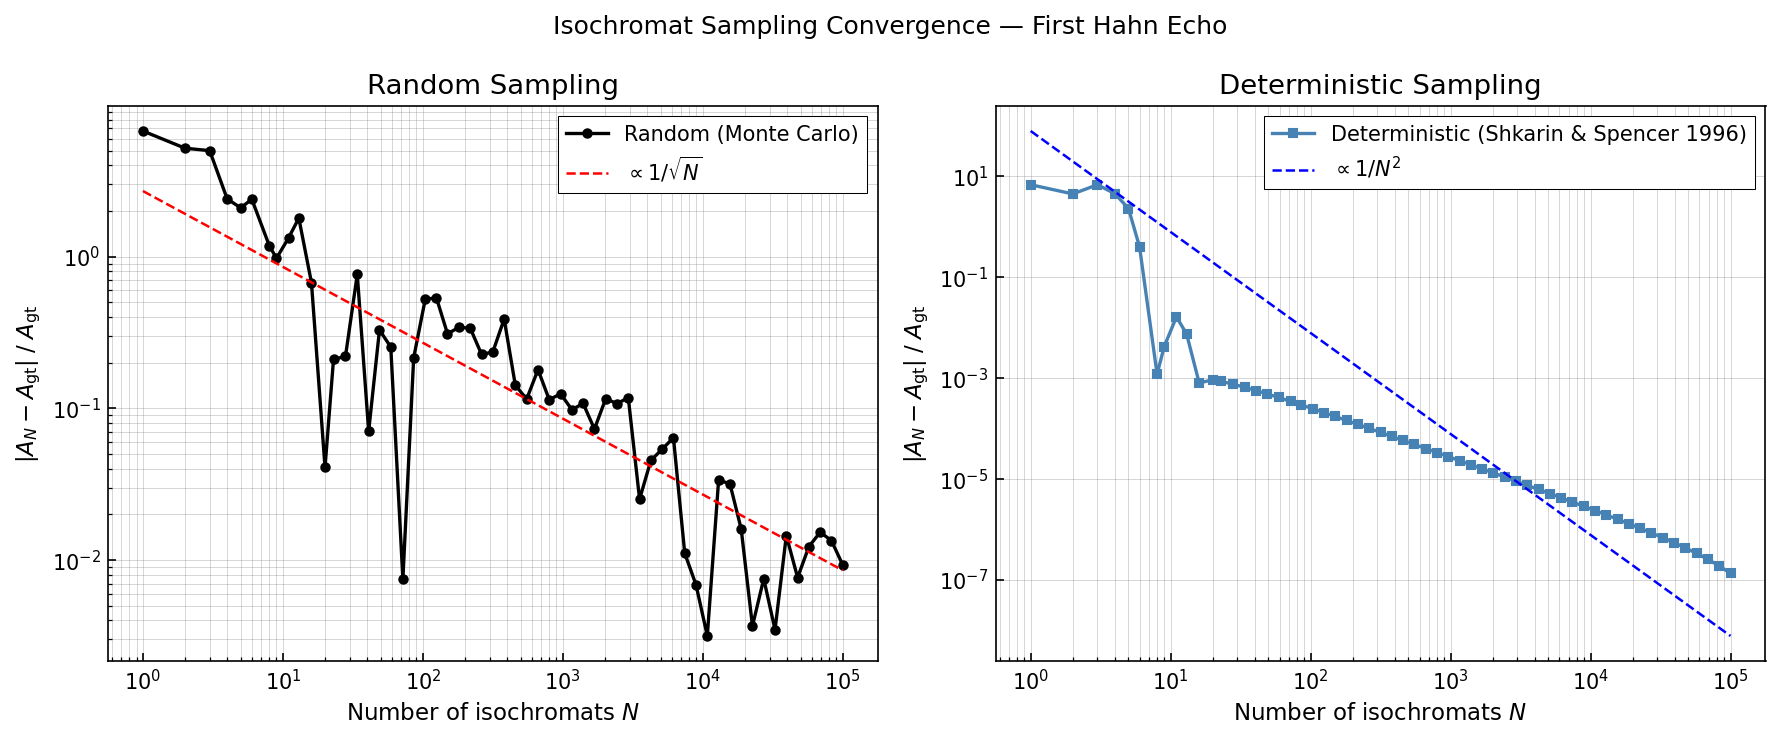

Saved to: /Users/danielmiksch/JupyterLab/optim/results/convergence


In [19]:
mpl.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.labelsize': 11, 'legend.fontsize': 10,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'axes.linewidth': 0.8, 'lines.linewidth': 1.8,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.major.size': 4, 'ytick.major.size': 4,
    'xtick.minor.visible': True, 'ytick.minor.visible': True,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

N_arr = N_values.astype(float)
N_ref = np.logspace(np.log10(N_arr[0]), np.log10(N_arr[-1]), 300)

# ── 1/√N reference: anchor at midpoint of N array ─────────────────────────
idx_rnd = len(N_arr) // 2
c_rnd = err_rnd[idx_rnd] * np.sqrt(N_arr[idx_rnd])
ref_rnd_y = c_rnd / np.sqrt(N_ref)

# ── 1/N² reference: anchor at 2/3 of N array (convergence regime) ──────────
idx_det = int(len(N_arr) * 2 // 3)
if err_det[idx_det] > 1e-10:
    c_det = err_det[idx_det] * N_arr[idx_det] ** 2
    ref_det_y = c_det / N_ref ** 2
else:
    ref_det_y = None

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ── Left: Random ───────────────────────────────────────────────────────────
ax1.loglog(N_arr, err_rnd, 'k-o', markersize=4, linewidth=1.6, label='Random (Monte Carlo)')
ax1.loglog(N_ref, ref_rnd_y, 'r--', linewidth=1.2, label=r'$\propto 1/\sqrt{N}$')
ax1.set_xlabel('Number of isochromats $N$')
ax1.set_ylabel(r'$|A_N - A_{\mathrm{gt}}|\;/\;A_{\mathrm{gt}}$')
ax1.set_title('Random Sampling')
ax1.grid(True, which='both', linewidth=0.3, color='gray', alpha=0.5)
leg1 = ax1.legend(frameon=True, fancybox=False, edgecolor='black', framealpha=1.0)
leg1.get_frame().set_linewidth(0.5)

# ── Right: Deterministic ───────────────────────────────────────────────────
ax2.loglog(N_arr, err_det, color='steelblue', marker='s', markersize=4,
           linewidth=1.6, linestyle='-', label='Deterministic (Shkarin & Spencer 1996)')
if ref_det_y is not None:
    ax2.loglog(N_ref, ref_det_y, 'b--', linewidth=1.2, label=r'$\propto 1/N^2$')
ax2.set_xlabel('Number of isochromats $N$')
ax2.set_ylabel(r'$|A_N - A_{\mathrm{gt}}|\;/\;A_{\mathrm{gt}}$')
ax2.set_title('Deterministic Sampling')
ax2.grid(True, which='both', linewidth=0.3, color='gray', alpha=0.5)
leg2 = ax2.legend(frameon=True, fancybox=False, edgecolor='black', framealpha=1.0)
leg2.get_frame().set_linewidth(0.5)

fig.suptitle('Isochromat Sampling Convergence — First Hahn Echo', fontsize=12)
fig.tight_layout()

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
fig.savefig(results_dir / f'iso_convergence_{timestamp}.pdf')
fig.savefig(results_dir / f'iso_convergence_{timestamp}.png')
plt.show()
print(f"Saved to: {results_dir}")

## Numerical Summary

In [21]:
header = f"{'N':>6}  {'A_rnd':>10}  {'A_det':>10}  {'err_rnd':>10}  {'err_det':>10}"
print(f"Ground truth A_gt = {A_gt:.8f}")
print()
print(header)
print('-' * len(header))
for k, N in enumerate(N_values):
    print(
        f"{N:>6d}  "
        f"{amp_rnd[k]:>10.6f}  "
        f"{amp_det[k]:>10.6f}  "
        f"{err_rnd[k]:>10.2e}  "
        f"{err_det[k]:>10.2e}"
    )

Ground truth A_gt = 0.07088748

     N       A_rnd       A_det     err_rnd     err_det
------------------------------------------------------
     1    0.547627    0.545785    6.73e+00    6.70e+00
     2    0.437992    0.382293    5.18e+00    4.39e+00
     3    0.424714    0.545073    4.99e+00    6.69e+00
     4    0.240949    0.385543    2.40e+00    4.44e+00
     5    0.219400    0.230922    2.10e+00    2.26e+00
     6    0.240195    0.043086    2.39e+00    3.92e-01
     8    0.154460    0.070972    1.18e+00    1.19e-03
     9    0.139985    0.071183    9.75e-01    4.17e-03
    11    0.165282    0.069743    1.33e+00    1.61e-02
    13    0.198006    0.070361    1.79e+00    7.43e-03
    16    0.118675    0.070944    6.74e-01    7.92e-04
    20    0.073775    0.070952    4.07e-02    9.17e-04
    23    0.085774    0.070948    2.10e-01    8.51e-04
    28    0.086486    0.070941    2.20e-01    7.49e-04
    34    0.125044    0.070933    7.64e-01    6.49e-04
    41    0.075891    0.070927   

## Interpretation

- **Random** error decreases as $1/\sqrt{N}$ — each doubling of $N$ reduces the error by $\approx 30\%$.
- **Deterministic** error decreases as $1/N^2$ — each doubling of $N$ reduces the error by $75\%$.
- For practical use, the deterministic mode reaches the same accuracy as random with far fewer isochromats.
- At small $N$ (1–3), both modes may show non-monotone behaviour:
  - Random: the single Monte Carlo draw can land anywhere on the Gaussian.
  - Deterministic: at $N=2$, both points land at $\pm 3.5\sigma$ (the distribution tails), so coverage is poor until $N$ is large enough to include points near the mean.